<a href="https://colab.research.google.com/github/zp0y/airline-recovery-project/blob/main/Airline_Recovery_After_COVID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Recovery After COVID-19

## EVA Air vs China Airlines

### Research Question

Which airline recovered faster after COVID-19 based on revenue performance?

In [5]:
import pandas as pd

eva_url = "https://raw.githubusercontent.com/zp0y/airline-recovery-project/main/20260603164148DataExport.xlsx"

cal_url = "https://raw.githubusercontent.com/zp0y/airline-recovery-project/main/20260603163759DataExport.xlsx"

eva = pd.read_excel(eva_url, header=1)

cal = pd.read_excel(cal_url, header=1)

print("EVA rows:", len(eva))
print("CAL rows:", len(cal))

EVA rows: 33
CAL rows: 33


In [6]:
eva.columns = [
    "Date",
    "NetIncome",
    "Revenue",
    "Assets",
    "Liabilities",
    "Equity",
    "CFO",
    "CFI",
    "CFF"
]

cal.columns = [
    "Date",
    "NetIncome",
    "Revenue",
    "Assets",
    "Liabilities",
    "Equity",
    "CFO",
    "CFI",
    "CFF"
]

eva["Company"] = "EVA Air"
cal["Company"] = "China Airlines"

df = pd.concat([eva, cal])

df.head()

,Date,NetIncome,Revenue,Assets,Liabilities,Equity,CFO,CFI,CFF,Company
0,2026/03,8268012,60515845,391276107,247236537,144039570,26186120,-8669136,-6074479,EVA Air
1,2025/12,26146437,220333377,364821777,217601893,147219884,55224615,-24882682,-21150505,EVA Air
2,2025/09,18497916,162686685,350659882,210306350,140353532,37280212,-21955257,-20627578,EVA Air
3,2025/06,12621994,110251392,354817769,219561494,135256275,23294897,-16196850,-8202011,EVA Air
4,2025/03,5929990,54944158,358468879,234565095,123903784,16452070,-6490286,-7183199,EVA Air


# Data Wrangling

The original datasets contained financial information for EVA Air and China Airlines.

The data cleaning process included:

- Renaming variables
- Standardizing column names
- Adding company labels
- Combining datasets

The final dataset contains quarterly financial data from 2018 to 2026.

In [7]:
df["Year"] = df["Date"].astype(str).str[:4]

annual = (
    df.groupby(["Company","Year"])
      .agg({"Revenue":"max"})
      .reset_index()
)

annual.head()

,Company,Year,Revenue
0,China Airlines,2018,170711607
1,China Airlines,2019,168444160
2,China Airlines,2020,115250550
3,China Airlines,2021,138841403
4,China Airlines,2022,150722471


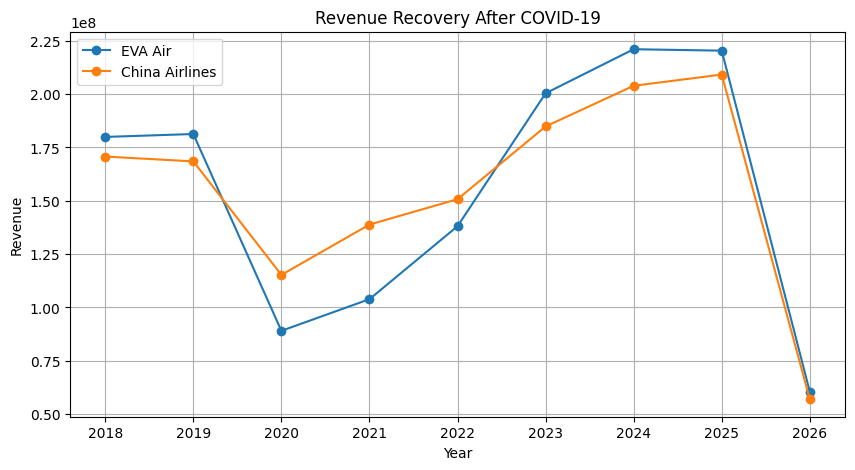

In [8]:
import matplotlib.pyplot as plt

eva_year = annual[
    annual["Company"]=="EVA Air"
]

cal_year = annual[
    annual["Company"]=="China Airlines"
]

plt.figure(figsize=(10,5))

plt.plot(
    eva_year["Year"],
    eva_year["Revenue"],
    marker="o",
    label="EVA Air"
)

plt.plot(
    cal_year["Year"],
    cal_year["Revenue"],
    marker="o",
    label="China Airlines"
)

plt.title("Revenue Recovery After COVID-19")

plt.xlabel("Year")

plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

# Findings

Both airlines experienced significant declines during the COVID-19 pandemic.

After travel restrictions were lifted, revenue gradually recovered.

EVA Air showed stronger revenue growth during the recovery period.

# Conclusion

This project compared the post-pandemic recovery of EVA Air and China Airlines.

Based on annual revenue performance, EVA Air recovered faster and achieved stronger growth after COVID-19.

Therefore, EVA Air demonstrated better financial recovery performance.